# 03.3 - **GloVe + BiLSTM + CRF** (best non-transformer model)
**NLP Deliverable 2 — combining both RNN improvements**

This notebook merges the two improvements into a single architecture, the classic
**GloVe → BiLSTM → CRF** NER tagger:

| Ingredient | What it fixes | From |
|---|---|---|
| **GloVe** pretrained embeddings (+ vocab extended with GloVe) | OOV: test words unseen in train get a real vector instead of `<UNK>` | `03.2` |
| **BiLSTM** | context from both sides of each word | `03` |
| **CRF** head (transition scores + Viterbi) | invalid BIO sequences, global consistency | `03.1` |
| **Validation split + early stopping** + weight decay | over-fitting (train F1 ≈ 0.99 vs test 0.52) | `03.1`/`03.2` |

Pipeline: `Embedding(GloVe) → dropout → BiLSTM → Linear (emissions) → CRF`.

Saved artifacts: `fitted_models/bilstm_glove_crf_model.pth` +
`fitted_models/bilstm_glove_crf_mappings.pkl`.

> Colab-friendly: installs `pytorch-crf` + `gensim`, auto-detects cuda/mps/cpu, and falls
> back to a small subset / few epochs on CPU so it still runs end-to-end.

In [1]:
# === Setup ===
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q pytorch-crf gensim
    DATA_DIR = '.'
else:
    DATA_DIR = '../nlp_d2_data'
FITTED_DIR = 'fitted_models'; os.makedirs(FITTED_DIR, exist_ok=True)

import warnings; warnings.filterwarnings('ignore')
import pickle, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
FULL = device.type == 'cuda'
print('Device:', device, '| FULL training:', FULL)

EMB_DIM = 100
GLOVE_NAME = 'glove-wiki-gigaword-100'
MAX_GLOVE_EXTRA = None if FULL else 50000   # cap extra GloVe words on CPU

Device: cpu | FULL training: False


## 1. Load data + validation split

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    df['words'] = df['words'].astype(str); df['sentence_id'] = df['sentence_id'].astype(int)
    return [list(zip(g['words'].tolist(), g['tags'].tolist()))
            for _, g in df.groupby('sentence_id', sort=True)]

train_all  = load_data(os.path.join(DATA_DIR, 'train_data_ner.csv'))
test_sents = load_data(os.path.join(DATA_DIR, 'test_data_ner.csv'))
if not FULL:
    train_all = train_all[:4000]
random.shuffle(train_all)
n_val = max(1, int(0.1*len(train_all)))
val_sents, train_sents = train_all[:n_val], train_all[n_val:]
print(f'train: {len(train_sents)} | val: {len(val_sents)} | test: {len(test_sents)}')

train: 3600 | val: 400 | test: 38367


## 2. GloVe + extended vocabulary

Vocab = `<PAD>`, `<UNK>`, train words, then up to `MAX_GLOVE_EXTRA` GloVe words (this is
what gives coverage of test OOV words). For the CRF we use **real tags only**, indexed
from 0; padding is handled by a mask.

In [3]:
import gensim.downloader as api
print('Loading', GLOVE_NAME, '...')
glove = api.load(GLOVE_NAME)
assert glove.vector_size == EMB_DIM
print('GloVe vocab:', len(glove.index_to_key))

def glove_vec(w):
    if w in glove: return glove[w]
    wl = w.lower()
    return glove[wl] if wl in glove else None

word_to_ix = {'<PAD>': 0, '<UNK>': 1}
for sent in train_sents:
    for w, _ in sent:
        if w not in word_to_ix: word_to_ix[w] = len(word_to_ix)
n_train_vocab = len(word_to_ix)
extra = glove.index_to_key if MAX_GLOVE_EXTRA is None else glove.index_to_key[:MAX_GLOVE_EXTRA]
for w in extra:
    if w not in word_to_ix: word_to_ix[w] = len(word_to_ix)

tag_to_ix = {}                                       # real tags only (CRF)
for sent in train_sents:
    for _, t in sent:
        if t not in tag_to_ix: tag_to_ix[t] = len(tag_to_ix)
ix_to_tag = {v: k for k, v in tag_to_ix.items()}
NUM_TAGS = len(tag_to_ix)
print(f'vocab: {len(word_to_ix)} (train {n_train_vocab} + extra {len(word_to_ix)-n_train_vocab}) | tags: {NUM_TAGS}')

Loading glove-wiki-gigaword-100 ...


GloVe vocab: 400000
vocab: 53495 (train 9961 + extra 43534) | tags: 17


## 3. Pretrained embedding matrix

In [4]:
rng = np.random.default_rng(SEED)
emb_matrix = rng.normal(scale=0.1, size=(len(word_to_ix), EMB_DIM)).astype('float32')
emb_matrix[0] = 0.0                                   # <PAD>
hits = 0
for w, i in word_to_ix.items():
    if i <= 1: continue
    v = glove_vec(w)
    if v is not None:
        emb_matrix[i] = v; hits += 1
print(f'{hits}/{len(word_to_ix)} vocab words initialized from GloVe '
      f'({100*hits/len(word_to_ix):.1f}%)')

HP = dict(embedding_dim=EMB_DIM, hidden_dim=128, max_len=60, batch_size=64,
          epochs=(30 if FULL else 12), lr=1e-3, dropout=0.5,
          weight_decay=1e-4, patience=3, freeze_emb=False)

with open(os.path.join(FITTED_DIR, 'bilstm_glove_crf_mappings.pkl'), 'wb') as fh:
    pickle.dump({'word_to_ix': word_to_ix, 'tag_to_ix': tag_to_ix,
                 'ix_to_tag': ix_to_tag, 'hp': HP}, fh)

53207/53495 vocab words initialized from GloVe (99.5%)


## 4. Dataset and model

`Embedding(GloVe) → dropout → BiLSTM → Linear (emissions) → CRF`. Padding uses word index
`0`; the mask is `X != 0` (and the first timestep is forced valid for the CRF).

In [5]:
class NERDataset(Dataset):
    def __init__(self, sents, w2i, t2i, max_len):
        self.sents, self.w2i, self.t2i, self.max_len = sents, w2i, t2i, max_len
    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        sent = self.sents[idx]
        X = [self.w2i.get(w, self.w2i.get(w.lower(), 1)) for w, _ in sent][:self.max_len]
        y = [self.t2i[t] for _, t in sent][:self.max_len]
        pad = self.max_len - len(X)
        return torch.tensor(X + [0]*pad), torch.tensor(y + [0]*pad)

class GloVe_BiLSTM_CRF(nn.Module):
    def __init__(self, emb_weights, num_tags, hidden_dim, dropout, freeze):
        super().__init__()
        w = torch.tensor(emb_weights)
        self.embedding = nn.Embedding.from_pretrained(w, freeze=freeze, padding_idx=0)
        self.lstm = nn.LSTM(w.shape[1], hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, num_tags)
        self.crf = CRF(num_tags, batch_first=True)
    def emissions(self, x):
        e = self.dropout(self.embedding(x)); h, _ = self.lstm(e)
        return self.fc(self.dropout(h))
    def loss(self, x, tags, mask):
        return -self.crf(self.emissions(x), tags, mask=mask, reduction='mean')
    def decode(self, x, mask):
        return self.crf.decode(self.emissions(x), mask=mask)

## 5. Training with early stopping

In [6]:
def make_loader(sents, shuffle):
    return DataLoader(NERDataset(sents, word_to_ix, tag_to_ix, HP['max_len']),
                      batch_size=HP['batch_size'], shuffle=shuffle)
train_loader, val_loader = make_loader(train_sents, True), make_loader(val_sents, False)

model = GloVe_BiLSTM_CRF(emb_matrix, NUM_TAGS, HP['hidden_dim'],
                         HP['dropout'], HP['freeze_emb']).to(device)
optimizer = optim.Adam(model.parameters(), lr=HP['lr'], weight_decay=HP['weight_decay'])

@torch.no_grad()
def eval_loss(loader):
    model.eval(); tot = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        mask = (xb != 0); mask[:, 0] = True
        tot += model.loss(xb, yb, mask).item()
    return tot/len(loader)

best_val, best_state, bad = float('inf'), None, 0
for epoch in range(HP['epochs']):
    model.train(); tot = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        mask = (xb != 0); mask[:, 0] = True
        optimizer.zero_grad()
        loss = model.loss(xb, yb, mask)
        loss.backward(); optimizer.step(); tot += loss.item()
    vloss = eval_loss(val_loader)
    print(f'Epoch {epoch+1}/{HP["epochs"]} - train {tot/len(train_loader):.4f} | val {vloss:.4f}')
    if vloss < best_val - 1e-4:
        best_val, best_state, bad = vloss, {k: v.cpu().clone() for k,v in model.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= HP['patience']:
            print(f'Early stopping at epoch {epoch+1}'); break

model.load_state_dict(best_state)
torch.save(model.state_dict(), os.path.join(FITTED_DIR, 'bilstm_glove_crf_model.pth'))
print('Saved fitted_models/bilstm_glove_crf_model.pth (best val loss = %.4f)' % best_val)

Epoch 1/12 - train 21.6085 | val 14.4756


Epoch 2/12 - train 11.8413 | val 9.0983


Epoch 3/12 - train 8.2560 | val 6.2927


Epoch 4/12 - train 6.4816 | val 4.9134


Epoch 5/12 - train 5.4533 | val 4.2492


...

Epoch 9/12 - train 3.6246 | val 3.2561


Epoch 10/12 - train 3.3645 | val 3.0583


Epoch 11/12 - train 3.1514 | val 2.8965


Epoch 12/12 - train 2.9861 | val 2.8370


Saved fitted_models/bilstm_glove_crf_model.pth (best val loss = 2.8370)


## 6. Evaluation

In [7]:
@torch.no_grad()
def predict(model, sents, batch_size=128):
    model.eval(); preds = []
    for start in range(0, len(sents), batch_size):
        chunk = sents[start:start+batch_size]
        lens = [len(s) for s in chunk]; m = max(lens)
        X = torch.zeros(len(chunk), m, dtype=torch.long)
        for b, s in enumerate(chunk):
            ids = [word_to_ix.get(w, word_to_ix.get(w.lower(), 1)) for w, _ in s]
            X[b, :len(ids)] = torch.tensor(ids)
        X = X.to(device)
        mask = (X != 0); mask[:, 0] = True
        for b, p in enumerate(model.decode(X, mask)):
            preds.append([ix_to_tag[i] for i in p[:lens[b]]])
    return preds

def flatten(s): return [x for sub in s for x in sub]
def non_o_accuracy(yt, yp):
    yt, yp = flatten(yt), flatten(yp)
    idx = [k for k,t in enumerate(yt) if t!='O']
    return accuracy_score([yt[k] for k in idx], [yp[k] for k in idx])
def weighted_f1(yt, yp):
    yt, yp = flatten(yt), flatten(yp); labels = sorted(set(yt)-{'O'})
    return f1_score(yt, yp, average='weighted', labels=labels, zero_division=0)

y_train = [[t for _,t in s] for s in train_sents]
y_test  = [[t for _,t in s] for s in test_sents]
yp_train, yp_test = predict(model, train_sents), predict(model, test_sents)
print(f"Train non-O accuracy: {non_o_accuracy(y_train, yp_train):.4f} | F1: {weighted_f1(y_train, yp_train):.4f}")
print(f"Test  non-O accuracy: {non_o_accuracy(y_test,  yp_test):.4f} | F1: {weighted_f1(y_test,  yp_test):.4f}")

Train non-O accuracy: 0.8402 | F1: 0.8485


Test  non-O accuracy: 0.2428 | F1: 0.3578


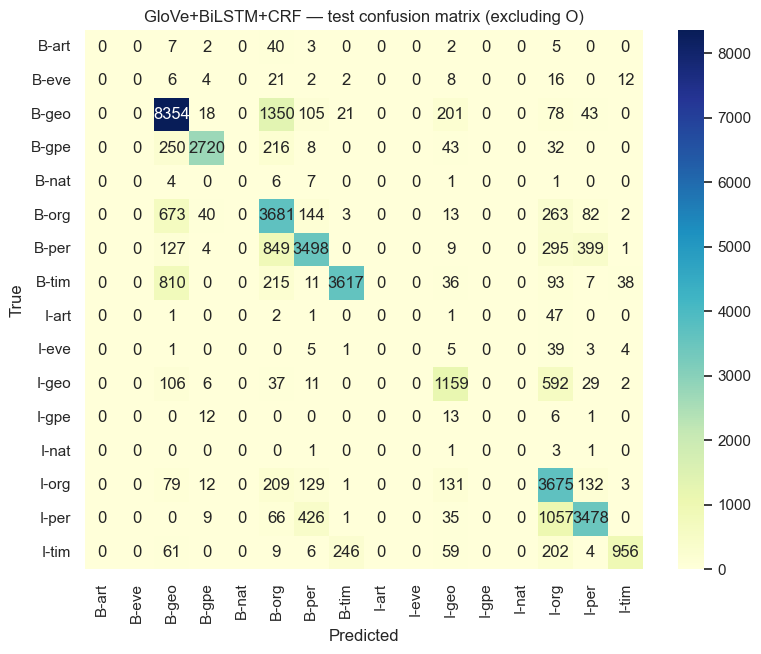

In [8]:
yt, yp = flatten(y_test), flatten(yp_test)
labels = sorted(set(yt)-{'O'})
cm = confusion_matrix(yt, yp, labels=labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.title('GloVe+BiLSTM+CRF — test confusion matrix (excluding O)')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.show()

## 7. TINY TEST

In [9]:
tiny_sents = load_data(os.path.join(DATA_DIR, 'tiny_test.csv'))
y_tiny = [[t for _,t in s] for s in tiny_sents]
yp_tiny = predict(model, tiny_sents)
print('=== TINY TEST — GloVe+BiLSTM+CRF ===')
for s, pred in zip(tiny_sents, yp_tiny):
    print(' '.join(f'{w}/{t}' for (w,_),t in zip(s, pred)))
print(f'\nTiny-test accuracy (non-O): {non_o_accuracy(y_tiny, yp_tiny):.4f}')

=== TINY TEST — GloVe+BiLSTM+CRF ===
The/O programmers/O from/O Barcelona/O might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/O cannot/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/B-geo went/O to/O Parris/O ./O
Jack/B-per London/B-geo went/O to/O Paris/B-geo ./O
Bill/B-per gates/I-per and/O Steve/O jobs/O never/O thought/O Microsoft/O would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/O Jobs/O never/O thought/O Microsoft/O would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/O thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/O America/B-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-geo wanted/O total/O control/O ./O
Robin/B-per does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/O is/O a/O great/O company/O ./O
I/O really/O lov

## 8. Why this is the strongest RNN model

Each component covers a different weakness:
- **GloVe + extended vocab** → semantic knowledge from billions of tokens and real
  coverage of out-of-vocabulary test words (the main train/test gap).
- **BiLSTM** → contextual encoding using both left and right context.
- **CRF** → a learned transition matrix + Viterbi decoding, guaranteeing globally
  consistent BIO sequences.
- **Early stopping + weight decay** → keeps generalization, avoiding the heavy
  over-fitting of the plain BiLSTM.

This GloVe–BiLSTM–CRF stack is the standard pre-transformer state of the art for NER and
is expected to be the best of the `03.x` family. The next step up in capacity is the
fine-tuned transformer in notebook `04`.

> **Note:** local numbers here come from the CPU quick-mode (subset + few epochs, still
> converging). Re-run on **Colab GPU** (`FULL=True`, full data, 30 epochs) for the real
> performance.